<a href="https://www.kaggle.com/code/ssevinc/price-prediction-with-random-forest?scriptVersionId=303868745" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Notebook Overview

This notebook implements a **Real Estate Price Prediction** model using  **Random Forest**.
And finally hyperparameter-tuning is applied to optimize model performance.

 Key Steps:
 
1️⃣ **Data Preprocessing**
   - Loaded dataset & validated columns
   - Feature scaling is applied using StandardScaler

2️⃣ **Visualizing Correlations**
   - Computed correlation matrix
   - Generated a heatmap using seaborn to identify feature relationships

3️⃣ **Model Training & Selection**
   - Random Forest with feature importance analysis
   - Hyperparameter tuning using GridSearchCV

4️⃣ **Performance Evaluation**
   - R² Score

#### Hyperparameter Tuning
The model fine-tuned **Random Forest Regression** with: 
   -  **GridSearchCV**

#### 📈 Results
The optimized **Random Forest model achieved an R² score of ~75%**, outperforming linear models.


In [1]:
import numpy as np 
import pandas as pd 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/real-estate-price-prediction/Real estate.csv


In [2]:
df = pd.read_csv("/kaggle/input/real-estate-price-prediction/Real estate.csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
print(df.isnull().sum())

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


In [4]:
df.corr()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,1.000000,-0.048658,-0.032808,-0.013573,-0.012699,-0.010110,-0.011059,-0.028587
X1 transaction date,-0.048658,1.000000,0.017549,0.060880,0.009635,0.035058,-0.041082,0.087491
X2 house age,-0.032808,0.017549,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
X3 distance to the nearest MRT station,-0.013573,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
X4 number of convenience stores,-0.012699,0.009635,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
X5 latitude,-0.010110,0.035058,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
X6 longitude,-0.011059,-0.041082,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
Y house price of unit area,-0.028587,0.087491,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


<Axes: >

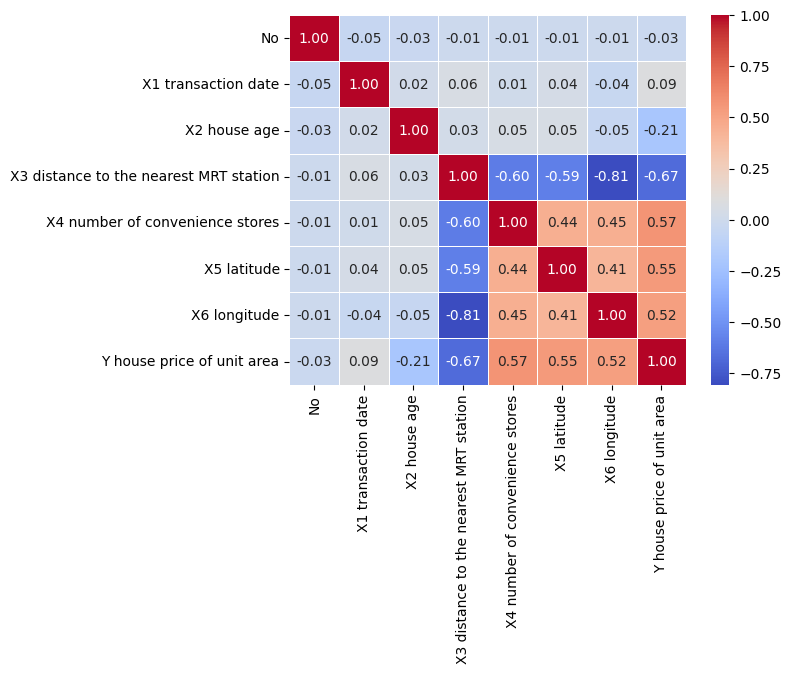

In [5]:
sns.heatmap(df.corr(),annot= True,cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [ ]:
sns.pairplot(df)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

In [ ]:
target = df['Y house price of unit area']
features = df[['X1 transaction date','X2 house age','X3 distance to the nearest MRT station','X4 number of convenience stores','X5 latitude','X6 longitude']]
x,y = features,target

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y, test_size = 0.3, random_state = 42
)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

In [ ]:
#y_pred = model.predict(x_test)
accuracy = r2_score(y_test,y_pred_rf)
print("Accuracy: {:.2f}%".format(accuracy*100))

In [ ]:

param_grid = {
    'n_estimators': [300, 400, 500],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train, y_train)

best_rf_grid = grid_search.best_estimator_

y_pred_rf_grid = best_rf_grid.predict(x_test)
r2_rf_grid = r2_score(y_test, y_pred_rf_grid)


In [ ]:
print("Best Grid Search Parameters:", grid_search.best_params_)
print(f"Final Optimized R² with GridSearchCV: {r2_rf_grid:.4f}")